# Data Analytics Project: Loan Default Risk Analysis

## Project Overview

This project focuses on analyzing loan default data to identify patterns, trends, and potential financial risk indicators within a lending portfolio.

Using Python and data analytics techniques, the dataset was cleaned, transformed, and explored through statistical analysis and visualization. The project aims to better understand borrower behavior and factors that may contribute to loan default risk.

The analysis includes:
- data cleaning and preparation
- exploratory data analysis (EDA)
- statistical analysis
- data visualization
- predictive modeling
- interactive dashboard development

Key areas explored throughout the project include:
- regional loan default patterns
- credit score distribution
- loan amount trends
- borrower financial indicators
- relationships between lending variables and default risk

Several visualizations and machine learning models were developed to support business intelligence insights and demonstrate how data analytics can assist financial institutions in making more informed lending decisions.

The final stage of the project includes an interactive dashboard built with Dash and Plotly to allow dynamic exploration of loan default trends and borrower risk factors.



In [ ]:
# Import the libraries
#import piplite
#await piplite.install('seaborn')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
%matplotlib inline
!pip install dash plotly


## Dataset Loading and Initial Exploration

The first step in the analysis process is loading the loan default dataset into a Pandas DataFrame for inspection and preparation.

At this stage, the dataset structure is reviewed to better understand:
- the number of rows and columns
- available financial variables
- borrower-related information
- overall dataset dimensions

Displaying all columns and adjusting output formatting helps improve readability during the exploratory analysis phase.

This initial inspection is important for identifying:
- missing values
- potential data quality issues
- relevant features for analysis
- opportunities for feature engineering and business insight development

In [ ]:
# Load the Dataset in pandas
df = pd.read_csv('Loan_Default.csv')

# Show me all columns in the ouput
desired_width=320
pd.set_option('display.width', desired_width)
pd.set_option('display.max_columns', None)

# Let's see the basic info about our dataset
# (rows, columns)
df.shape


(148670, 36)

## Understanding the Dataset Structure

Before beginning data cleaning and analysis, it is important to examine the structure and data types within the dataset.

The `info()` function provides a summary of:
- column names
- data types
- non-null values
- memory usage

This step helps identify:
- missing or incomplete data
- incorrect data types
- categorical versus numerical variables
- columns that may require transformation before analysis

Understanding the dataset structure is essential for ensuring accurate data preparation, visualization, and predictive modeling throughout the project.

In [ ]:
# Types of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   date of the loan           148670 non-null  object 
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

## Previewing the Dataset

To better understand the contents of the dataset, the first five rows are displayed using the `head()` function.

This initial preview provides a snapshot of:
- borrower information
- loan characteristics
- financial variables
- default status indicators

Reviewing sample records helps verify that the dataset loaded correctly and provides an early understanding of the data that will be analyzed throughout the project.

This step also assists in identifying:
- column relevance
- formatting inconsistencies
- potential cleaning requirements
- relationships between variables

In [ ]:
# First 5 rows of the dataset
df.head()

,ID,date of the loan,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,month,quarter
0,24890,5/1/2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0,5,2
1,24891,12/1/2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN,12,4
2,24892,9/1/2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0,9,3
3,24893,7/1/2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0,7,3
4,24894,3/1/2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0,3,1


## Standardizing Column Names

Before beginning data analysis and visualization, the dataset column names are standardized to improve consistency and reduce potential coding errors.

The column names are cleaned by:
- removing extra spaces
- converting all text to lowercase
- replacing spaces and hyphens with underscores

Standardizing column names helps:
- simplify data manipulation
- improve code readability
- prevent case-sensitive errors
- create a cleaner workflow for analysis and dashboard development

This step is considered a best practice in data preparation and helps ensure more reliable downstream analysis.

In [ ]:
# STANDARDIZE COLUMN NAMES

# Before doing anything, we fix all column names so they are:
#   - all lowercase
#   - spaces replaced with underscores
# This avoids case mismatch errors later in the code.

df.columns = (df.columns
              .str.strip()           # remove extra spaces
              .str.lower()           # make everything lowercase
              .str.replace(" ", "_")
              .str.replace("-", "_")) # replace spaces with underscores

print("Cleaned column names:")
print(df.columns.tolist())
print()

Cleaned column names:
['id', 'date_of_the_loan', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'credit_worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'interest_rate_spread', 'upfront_charges', 'term', 'neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type', 'credit_score', 'co_applicant_credit_type', 'age', 'submission_of_application', 'ltv', 'region', 'security_type', 'status', 'dtir1', 'month', 'quarter']



## Identifying Missing Values

Real-world datasets often contain incomplete or missing information, which can affect the accuracy of analysis and predictive modeling.

In this step, the dataset is checked for missing values across all columns to identify potential data quality issues.

Understanding missing data is important because:
- incomplete records can introduce bias into the analysis
- missing financial information may impact model performance
- certain variables may require cleaning or imputation before visualization and prediction

This process helps determine:
- which columns contain missing values
- the extent of missing data
- appropriate data-cleaning strategies for the next stage of the project

In [ ]:
# Handle Missing Values

# First, let's SEE which columns have missing values and how many
#creates a header
print("=" * 50)
print(" Missing Values")
print("=" * 50)

# checks every single cell and returns True if it's empty, False if it has a value
# counts all the true values per column
print(df.isnull().sum())
print()

 Missing Values
id                               0
date_of_the_loan                 0
loan_limit                    3344
gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
credit_worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
interest_rate_spread         36639
upfront_charges              39642
term                            41
neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
secured_by                       0
total_units                      0
income                        9150
credit_type                      0
credit_score                     0
co_applicant_credit_type         0
age                            200
subm

## Analyzing the Percentage of Missing Data

After identifying missing values within the dataset, the next step is to measure the percentage of missing data in each column.

Calculating missing value percentages provides a clearer understanding of the overall data quality and helps determine whether:
- missing records can be reasonably filled
- certain variables require further cleaning
- columns contain excessive missing information
- specific features may impact analysis reliability

This step is important because high percentages of missing data can reduce the accuracy of:
- statistical analysis
- visualizations
- predictive modeling
- business insights

Understanding the scale of missing data supports more informed data-cleaning decisions before moving into exploratory analysis and modeling.

In [ ]:
# SEE THE PERCENTAGE OF MISSING VALUES

# WHAT PERCENTAGE of the column is missing.
print("=" * 50)
print(" Missing Values (%)")
print("=" * 50)

# len(df)   total number of rows
# * 100     convert to percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

# round(2)  show only 2 decimal places
print(missing_percent.round(2))
print()

 Missing Values (%)
id                            0.00
date_of_the_loan              0.00
loan_limit                    2.25
gender                        0.00
approv_in_adv                 0.61
loan_type                     0.00
loan_purpose                  0.09
credit_worthiness             0.00
open_credit                   0.00
business_or_commercial        0.00
loan_amount                   0.00
rate_of_interest             24.51
interest_rate_spread         24.64
upfront_charges              26.66
term                          0.03
neg_ammortization             0.08
interest_only                 0.00
lump_sum_payment              0.00
property_value               10.16
construction_type             0.00
occupancy_type                0.00
secured_by                    0.00
total_units                   0.00
income                        6.15
credit_type                   0.00
credit_score                  0.00
co_applicant_credit_type      0.00
age                           0.13


## Reviewing Columns with Missing Data

To better focus the data-cleaning process, the analysis isolates only the columns that contain missing values.

Rather than reviewing every column in the dataset, this step highlights the variables that may require:
- data imputation
- removal of incomplete records
- further investigation
- additional preprocessing

Identifying only the affected columns improves efficiency and helps prioritize which financial and borrower-related variables may impact the reliability of the analysis.

This targeted review supports cleaner data preparation before moving into exploratory analysis and predictive modeling.

In [ ]:

# SHOW ONLY COLUMNS THAT HAVE MISSING VALUES

# Filtering the columns that actually have missing values.
print("=" * 50)
print(" Columns WITH Missing Values Only")
print("=" * 50)

# missing_percent > 0   keeps only columns where missing % is above 0
cols_with_missing = missing_percent[missing_percent > 0]

if len(cols_with_missing) == 0:
    print("No missing values found.")
else:
    print(cols_with_missing.round(2))
print()

 Columns WITH Missing Values Only
loan_limit                    2.25
approv_in_adv                 0.61
loan_purpose                  0.09
rate_of_interest             24.51
interest_rate_spread         24.64
upfront_charges              26.66
term                          0.03
neg_ammortization             0.08
property_value               10.16
income                        6.15
age                           0.13
submission_of_application     0.13
ltv                          10.16
dtir1                        16.22
dtype: float64



## Handling Missing Numerical Values

To improve data quality and prepare the dataset for analysis, missing values within key numerical columns are filled using the median value of each variable.

The median is used instead of the average (mean) because it is less affected by extreme values and outliers, making it a more reliable representation of the typical borrower profile.

The selected columns include important financial and lending-related variables such as:
- interest rates
- loan terms
- property values
- applicant income
- debt-to-income ratios
- loan-to-value ratios

Filling missing numerical values helps:
- preserve more records for analysis
- improve consistency across the dataset
- support more reliable visualizations and predictive modeling
- reduce bias caused by incomplete financial information

This step is an important part of preparing real-world financial data for business analysis and machine learning workflows.

In [ ]:
# NORMALIZED THE DATA: FILL IN MISSING VALUES — NUMBER COLUMNS WITH MEDIAN

# We use median instead of average (mean) because:
#   Average is affected by very large or very small numbers
#   Median stays closer to the "typical" value

numeric_cols_to_fill = [
    "rate_of_interest",     # annual interest rate
    "interest_rate_spread", # difference from benchmark rate
    "upfront_charges",      # fees paid at loan start
    "term",                 # loan duration in months
    "property_value",       # estimated property value
    "income",               # applicant's income
    "ltv",                  # loan-to-value ratio
    "dtir1"                 # debt-to-income ratio
]

# Fill all empty cells with the median in one line
df[numeric_cols_to_fill] = df[numeric_cols_to_fill].fillna(df[numeric_cols_to_fill].median())   # The inner part calculates the median for each column separately.
                                                                                                # the outer part Fills every empty cell with the median value of that column.
# Confirm and grabs only the numeric columns we just filled
print("Missing values after filling:")                                                          # .isnull() Marks every empty cell as True, filled cell as False
print(df[numeric_cols_to_fill].isnull().sum())                                                  # .sum()Counts all the True values per column
print()

Missing values after filling:
rate_of_interest        0
interest_rate_spread    0
upfront_charges         0
term                    0
property_value          0
income                  0
ltv                     0
dtir1                   0
dtype: int64



## Handling Missing Categorical Values

In addition to numerical data, the dataset also contains categorical variables that describe borrower and loan characteristics.

Rows containing missing values within key categorical columns were removed to improve data consistency and ensure more reliable analysis results.

The selected columns include important lending-related categories such as:
- loan type and limits
- loan purpose
- application method
- borrower age group
- pre-approval status
- amortization behavior

Because categorical variables are used extensively in grouping, visualization, and risk analysis, incomplete records may reduce the accuracy of business insights and trend interpretation.

This step also measures:
- how many records were removed
- the percentage of data lost during cleaning
- the remaining dataset size after preprocessing

Monitoring data loss is important to ensure that the cleaning process does not significantly reduce the quality or representativeness of the dataset.

In [ ]:

# NORMALIZED THE DATA: DROP ROWS WITH MISSING CATEGORICAL VALUES
# These are the TEXT columns in our dataset

#Shows teh rows before dropping
rows_before = len(df)

# Drop rows where any of these columns have an empty cell                         # df.dropna() Removes rows that have empty cells
df = df.dropna(subset=[                                                           # subset=[...] Only checks these specific columns for empty cells
    "loan_limit",               # conforming or non-conforming loan
    "approv_in_adv",            # was the loan pre-approved?
    "loan_purpose",             # buy, refinance, or build?
    "neg_ammortization",        # does the debt grow over time?
    "age",                      # age group of the applicant
    "submission_of_application",# applied directly or through a broker?
])

rows_after  = len(df)                                                             # How many rows are left after dropping
rows_dropped = rows_before - rows_after                                           # How many rows were dropped
percent_dropped = (rows_dropped / rows_before) * 100                              # What percentage of data was lost

print("=" * 50)
print(" Drop Rows Results")
print("=" * 50)
print(f"  Rows before : {rows_before:,}")                                           # :,   Inserts the number with comma separators
print(f"  Rows dropped: {rows_dropped:,} ({percent_dropped:.2f}%)")                 # :.2f Shows exactly 2 decimal places
print(f"  Rows after  : {rows_after:,}")
print()

 Drop Rows Results
  Rows before : 143,983
  Rows dropped: 0 (0.00%)
  Rows after  : 143,983



## Verifying Data Cleaning Results

After handling missing numerical and categorical values, the dataset is reviewed again to confirm that the cleaning process was successful.

This validation step checks whether:
- any missing values still remain
- all required variables are complete
- the dataset is ready for analysis and visualization

Ensuring a clean dataset is critical because incomplete data can negatively impact:
- statistical accuracy
- business insights
- visualization quality
- predictive modeling performance

A fully cleaned dataset provides a stronger foundation for reliable exploratory analysis, machine learning, and dashboard development.

In [ ]:
# CONFIRM THE DATASET IS CLEAN

print("=" * 50)
print(" Missing Values AFTER Dropping")
print("=" * 50)
print(df.isnull().sum())                                                          # First .sum() counts missing values per column (gives a list of numbers)
print()

total_missing = df.isnull().sum().sum()                                           # Second .sum() adds all those numbers together into one total
if total_missing == 0:                                                            # If total_missing == 0, the dataset is completely clean
    print("Dataset is fully clean — no missing values remain!")
else:
    print(f"Warning: {total_missing} missing values still remain.")
print()

 Missing Values AFTER Dropping
id                           0
date_of_the_loan             0
loan_limit                   0
gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
credit_worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
interest_rate_spread         0
upfront_charges              0
term                         0
neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
secured_by                   0
total_units                  0
income                       0
credit_type                  0
credit_score                 0
co_applicant_credit_type     0
age                          0
submission_of_application    0
ltv                          0
region                       0
security

## Removing Duplicate Records

Duplicate records can negatively impact data analysis by artificially inflating counts, skewing statistics, and introducing misleading patterns within the dataset.

In this step, the dataset is checked for fully duplicated rows and any repeated records are removed.

Removing duplicate entries helps:
- improve data accuracy
- ensure more reliable statistical analysis
- prevent distorted visualizations
- support more trustworthy predictive modeling results

The process also confirms:
- how many duplicate records were identified
- how many rows remained after cleaning
- whether the dataset was already free of duplicate entries

This step is an important part of maintaining overall data integrity before moving into exploratory analysis and business insight generation.

In [ ]:

# REMOVE DUPLICATE ROWS

# A duplicate row = a row that is 100% identical to another row
# Keeping duplicates would give us false results in our analysis

# Count duplicates BEFORE removing them                                           # Looks at every row — marks it True if it's a copy, False if it's unique
duplicates_found = df.duplicated().sum()                                          # Counts all the True values

print("=" * 50)
print(" Duplicate Rows")
print("=" * 50)
print(f"  Duplicates found: {duplicates_found:,}")                                # Inserts the number with comma separators
print()

# Remove the duplicate rows
# keep="first" means we keep the first time a row appears
# and delete every repeated copy after that
df = df.drop_duplicates(keep="first")

# Confirm the result
print("=" * 50)
print(" After Removing Duplicates")
print("=" * 50)
print(f"  Rows remaining: {len(df):,}")                                           # len(df) counts the rows after the duplicates were removed. This confirms the new size of your dataset.
print()

if duplicates_found == 0:                                                         # If duplicates_found == 0, No duplicates existed — nothing was removed
    print("No duplicates found — dataset was already clean!")
else:                                                                             # If duplicates_found > 0, duplicates were found and removed
    print(f"{duplicates_found:,} duplicate rows removed successfully!")

 Duplicate Rows
  Duplicates found: 0

 After Removing Duplicates
  Rows remaining: 143,983

No duplicates found — dataset was already clean!


## Reviewing Data Types

Before moving into analysis and visualization, the dataset data types are reviewed to ensure variables are correctly interpreted by Python.

This step helps confirm:
- numerical variables are stored correctly
- categorical fields are properly formatted
- columns are ready for statistical analysis and visualization

Validating data types is important for preventing errors during data processing and predictive modeling workflows.

In [ ]:
# CHECK DATA TYPES

# Review dataset data types to ensure variables are correctly formatted
df.dtypes

,0
id,int64
date_of_the_loan,object
loan_limit,object
gender,object
approv_in_adv,object
loan_type,object
loan_purpose,object
credit_worthiness,object
open_credit,object
business_or_commercial,object


## Confirming the Final Dataset Size

After completing the data-cleaning process, the final dataset dimensions are reviewed to confirm that the data is ready for analysis.

This step helps verify:
- the total number of remaining records
- the number of available variables
- the impact of data-cleaning operations on the dataset size

Reviewing the final dataset shape ensures that:
- missing values were handled successfully
- duplicate records were removed
- sufficient data remains for reliable analysis and visualization

The cleaned dataset is now prepared for exploratory data analysis, business insight generation, and predictive modeling.

In [ ]:
# Checking the new clean dataset ready to work
df.shape

(143983, 36)

## Previewing the Cleaned Dataset

After completing the data-cleaning and preprocessing steps, the first five rows of the updated dataset are displayed to verify the results.

This preview helps confirm that:
- missing values were handled correctly
- duplicate records were removed
- column names were standardized
- the dataset structure is consistent and ready for analysis

Reviewing the cleaned dataset provides a final validation step before beginning exploratory data analysis, visualization, and predictive modeling.

In [ ]:
# Show the first 5 rows of the new dataset
df.head()

,id,date_of_the_loan,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,secured_by,total_units,income,credit_type,credit_score,co_applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,month,quarter
0,24890,5/1/2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,3.99,0.3904,2596.45,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0,5,2
1,24891,12/1/2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,3.99,0.3904,2596.45,360.0,not_neg,not_int,lpsm,418000.0,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,75.135870,North,direct,1,39.0,12,4
2,24892,9/1/2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.00,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0,9,3
3,24893,7/1/2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,2596.45,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0,7,3
4,24894,3/1/2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.00,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0,3,1


## Descriptive Statistical Analysis

Descriptive statistics are used to summarize the main characteristics of the numerical variables within the dataset.

This analysis provides key statistical measures such as:
- mean
- median
- minimum values
- maximum values
- standard deviation
- quartiles

Reviewing these statistics helps identify:
- overall borrower and loan trends
- value distributions
- potential outliers
- unusual financial patterns within the dataset

Descriptive analysis provides an important foundation for understanding the data before moving into deeper exploratory analysis, visualization, and predictive modeling.

In [ ]:
# Run some statistics
df.describe()

,id,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,status,dtir1,month,quarter
count,143983.000000,1.439830e+05,143983.000000,143983.000000,143983.000000,143983.000000,1.439830e+05,143983.000000,143983.000000,143983.000000,143983.000000,143983.000000,143983.000000,143983.000000
mean,99210.421015,3.317719e+05,4.027587,0.426660,3062.710547,335.093025,4.912121e+05,6889.314572,699.692672,72.937432,0.244959,37.927721,6.521978,2.500670
std,42924.488901,1.842255e+05,0.489740,0.446424,2803.361507,58.443407,3.432893e+05,6303.051328,115.891056,38.367574,0.430065,9.667286,3.209283,1.053722
min,24890.000000,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000,1.000000,1.000000
25%,62036.500000,1.965000e+05,3.750000,0.178100,1250.000000,360.000000,2.880000e+05,3840.000000,599.000000,63.141809,0.000000,33.000000,4.000000,2.000000
50%,99169.000000,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000,6.000000,2.000000
75%,136384.500000,4.365000e+05,4.250000,0.617100,3900.515000,360.000000,5.980000e+05,8280.000000,800.000000,84.574468,0.000000,44.000000,9.000000,3.000000
max,173559.000000,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000,12.000000,4.000000


### Exploratory Data Analysis (EDA)

This section focuses on analyzing loan default patterns and identifying key business insights within the dataset.

The analysis includes:
- summary statistics
- regional comparisons
- loan trend analysis
- borrower risk patterns
- outlier detection

Several visualizations were developed to better understand:
- default behavior
- lending risk
- borrower characteristics
- regional performance trends

The goal of this analysis is to transform raw financial data into actionable business insights that support data-driven lending decisions.






In [ ]:
"""
•	Perform analysis:
o	Summary stats (mean, min, max)
o	Group analysis (category, region, time trends)
"""

df.describe()[['income', 'loan_amount', 'credit_score', 'property_value', 'ltv']]

,income,loan_amount,credit_score,property_value,ltv
count,143983.000000,1.439830e+05,143983.000000,1.439830e+05,143983.000000
mean,6889.314572,3.317719e+05,699.692672,4.912121e+05,72.937432
std,6303.051328,1.842255e+05,115.891056,3.432893e+05,38.367574
min,0.000000,1.650000e+04,500.000000,8.000000e+03,0.967478
25%,3840.000000,1.965000e+05,599.000000,2.880000e+05,63.141809
50%,5760.000000,2.965000e+05,699.000000,4.180000e+05,75.135870
75%,8280.000000,4.365000e+05,800.000000,5.980000e+05,84.574468
max,578580.000000,3.576500e+06,900.000000,1.650800e+07,7831.250000


## Loan Default Distribution Analysis

To better understand borrower repayment behavior, the distribution of loan status categories is analyzed.

Calculating the percentage distribution of defaulted versus non-defaulted loans helps identify:
- the overall balance of the dataset
- the proportion of higher-risk borrowers
- potential class imbalance within the target variable

Understanding the distribution of loan outcomes is important because:
- highly imbalanced datasets can affect predictive modeling performance
- default rates provide insight into overall lending risk
- repayment trends help support financial risk assessment and business decision-making

This analysis provides an initial overview of how common loan defaults are within the lending portfolio.

In [ ]:
# Calculate the percentage distribution of each loan status category
# normalize=True converts counts into proportions (0–1), so multiplying by 100 gives percentages
value= df['status'].value_counts(normalize=True) * 100

# Convert the result into a DataFrame for cleaner display
value.to_frame()


,proportion
status,
0,75.504053
1,24.495947


## Group Analysis: Loan Type and Lending Patterns

Group analysis is used to compare lending behavior across different loan categories and identify potential trends within the dataset.

In this section, the average loan amount is analyzed by loan type to better understand:
- differences in lending patterns
- borrower financing behavior
- variations in loan size across categories

Comparing average loan amounts across loan types may help reveal:
- which loan categories receive larger financing amounts
- potential differences in borrower profiles
- areas of increased financial exposure for lenders

This type of analysis supports business intelligence by helping financial institutions better understand how lending activity varies across different segments of the loan portfolio.

In [ ]:
# Group analysis (category, region, time trends)

# by category
df.groupby('loan_type')['loan_amount'].mean()


,loan_amount
loan_type,
type1,343960.480974
type2,258056.615616
type3,340887.783498


## Loan Default Distribution by Loan Type

This analysis examines how loan default outcomes are distributed across different loan categories.

By calculating the percentage distribution of loan status within each loan type, the analysis helps identify:
- which loan categories have higher proportions of defaults
- differences in repayment behavior across lending segments
- potential areas of elevated financial risk

Understanding how default rates vary by loan type is important because certain lending categories may carry:
- higher borrower risk
- different financial characteristics
- varying repayment patterns

These insights can help financial institutions:
- improve lending strategies
- strengthen risk assessment models
- identify higher-risk loan segments
- support more informed portfolio management decisions

In [ ]:
# Group the dataset by loan_type and calculate the percentage distribution of each status category

df_group=df.groupby('loan_type',as_index=False)['status'].value_counts(normalize=True)

### Business Insight: Default Rate by Region

This analysis compares average loan default rates across regions.

The North-East region shows the highest average default rate, while the North region shows the lowest. This suggests that borrower risk may vary by geography, which is important for lenders when assessing portfolio exposure.

Higher-default regions may require closer review of borrower profiles, stronger risk controls, or adjusted lending strategies. Lower-default regions may represent more stable lending segments with reduced repayment risk.

In [ ]:
# By region
df.groupby('region')['status'].mean().sort_values(ascending=False)

,status
region,
North-East,0.301574
central,0.275095
south,0.263606
North,0.224571


### Business Insight: Default Rate by Region

This visualization highlights differences in loan default rates across geographic regions.

The North-East region demonstrated a higher average default rate compared to other regions, which may indicate elevated lending risk or reduced borrower financial stability in that area.

Regions with consistently higher default rates may require:
- stricter loan approval criteria
- enhanced risk assessment models
- additional borrower verification
- adjusted interest rates to offset financial risk

Lower-default regions may represent more stable lending opportunities with reduced financial exposure for lenders.

Understanding regional performance helps financial institutions optimize lending strategies and improve portfolio risk management.

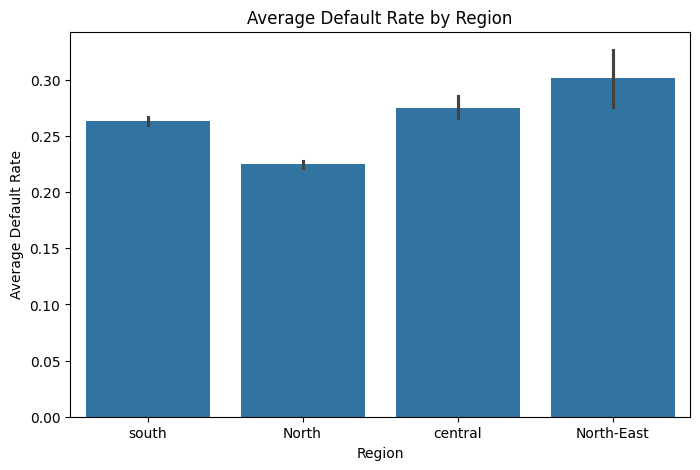

In [ ]:
#----------------CREATE BAR CHART FOR VISUALIZATION-------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='region',
    y='status',
    estimator='mean'
)

plt.title("Average Default Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Default Rate")

plt.show()


## Heatmap Analysis: Loan Status Distribution by Loan Type

The heatmap visualization compares the proportion of defaulted and non-defaulted loans across different loan categories.

By displaying the percentage distribution of loan outcomes within each loan type, the heatmap helps highlight:
- differences in repayment behavior
- potential variations in lending risk
- patterns within specific loan categories

The color intensity provides a quick visual indication of where higher concentrations of loan defaults may exist.

This analysis supports business decision-making by helping financial institutions:
- identify higher-risk lending segments
- compare loan performance across categories
- evaluate portfolio risk exposure
- improve underwriting and lending strategies

Heatmaps are especially useful for quickly identifying patterns and relationships within large financial datasets.

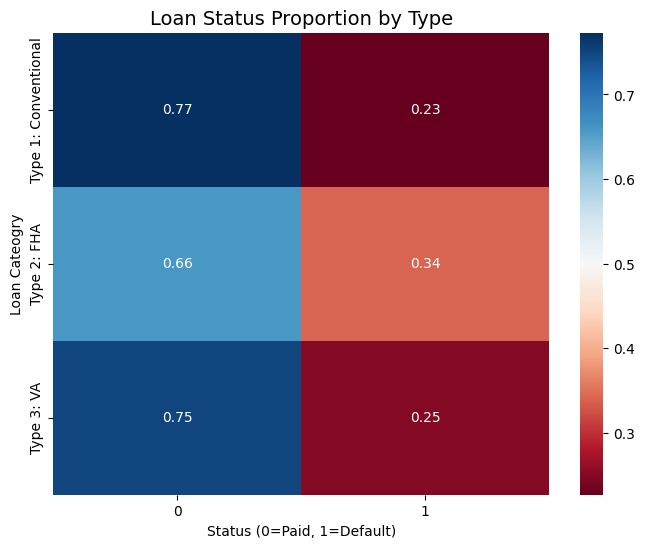

In [ ]:
# Pivot the grouped data so that:
# - Rows represent each loan_type
# - Columns represent each status category (e.g., 1= Default, 0= Non-Default /Paid)
# - Values represent the proportion (%) of each status within each loan_type

grouped_pivot=df_group.pivot(index='loan_type', columns='status', values='proportion')
grouped_pivot.index=['Type 1: Conventional', 'Type 2: FHA', 'Type 3: VA']
plt.figure(figsize=(8,6))
sns.heatmap(grouped_pivot, annot=True,cmap='RdBu')
#plt.pcolor(grouped_pivot, cmap='RdBu')
plt.title("Loan Status Proportion by Type", fontsize=14)
plt.ylabel("Loan Cateogry")
plt.xlabel("Status (0=Paid, 1=Default)")
plt.show()


#df_group= df.groupby(['region'], ['status'], as_index=False)

## Correlation Analysis: Loan Amount and Borrower Income

Correlation analysis is used to measure the strength and direction of the relationship between borrower income and loan amount.

The Pearson correlation coefficient helps determine whether:
- higher borrower income is associated with larger loan amounts
- the relationship between the variables is weak, moderate, or strong
- changes in one variable tend to correspond with changes in the other

The accompanying p-value is used to evaluate the statistical significance of the relationship and determine whether the observed correlation is likely meaningful rather than occurring by chance.

Understanding the relationship between income and loan amount is important because borrower income is often a key factor in:
- lending eligibility
- risk assessment
- loan approval decisions
- repayment capacity evaluation

This analysis provides insight into how financial variables may influence lending patterns within the dataset.

In [ ]:
# Calculate Pearson correlation and p‑value between loan amount and income

pearson_coef,p_value=stats.pearsonr(df['loan_amount'], df['income'])
pearson_coef

np.float64(0.44194511998099645)

## Time Trend Analysis: Monthly Loan Volume (2019)

This line chart visualizes total loan volume across each month in 2019, helping identify lending activity trends throughout the year.

The analysis reveals that:

- Loan volume was lowest during January and February.
- Lending activity increased sharply beginning in March.
- The highest loan volume occurred between April and June, peaking in June at approximately 4.8 billion dollars.
- After June, loan volume gradually declined through the remainder of the year.
- The lowest lending activity during the second half of the year occurred in November and December.

These trends may indicate seasonal borrowing behavior, changing market demand, or fluctuations in lending activity throughout the year.

This visualization helps stakeholders better understand periods of high and low lending activity and supports financial trend analysis and lending risk evaluation.

In [108]:
# Create year and month columns

df["date_of_the_loan"] = pd.to_datetime(
    df["date_of_the_loan"],
    errors="coerce"
)

df["year"] = df["date_of_the_loan"].dt.year

df["month"] = df["date_of_the_loan"].dt.month

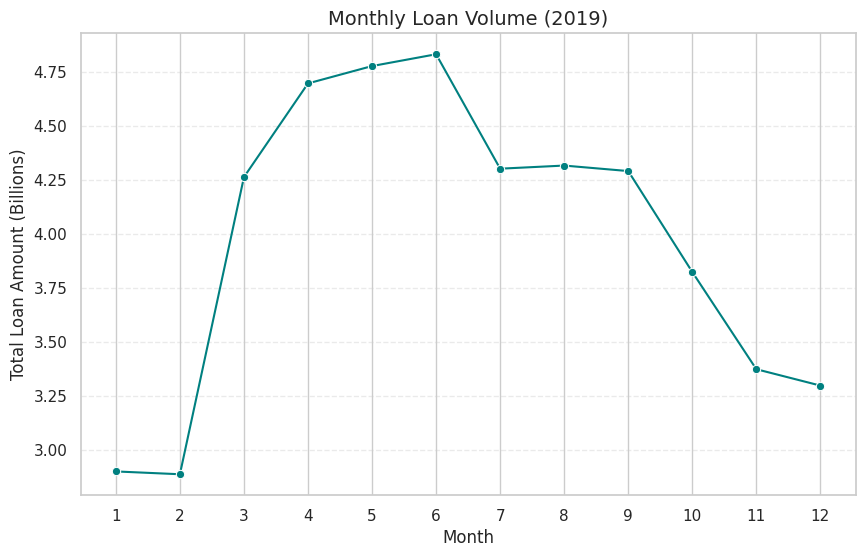

In [111]:
# Monthly Loan Volume Trend

monthly_volume = df.groupby("month")["loan_amount"].sum().reset_index()

monthly_volume["loan_amount"] = monthly_volume["loan_amount"] / 1_000_000_000

plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_volume,
    x="month",
    y="loan_amount",
    marker="o",
    color="teal"
)

plt.title("Monthly Loan Volume (2019)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Loan Amount (Billions)")

plt.xticks(range(1,13))

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

## Visualization Analysis: Default Rate by Loan Purpose

This bar chart compares average loan default rates across different loan purposes to identify which lending categories may carry higher financial risk.

Analyzing default probability by loan purpose helps reveal:
- differences in borrower repayment behavior
- lending categories associated with increased default risk
- potential trends in borrower financial stability

Higher default rates within certain loan purposes may indicate:
- increased financial pressure on borrowers
- higher-risk lending segments
- greater uncertainty in repayment capacity

Understanding these patterns can help financial institutions:
- improve risk assessment strategies
- refine loan approval criteria
- adjust lending policies by loan category
- strengthen portfolio risk management practices

This visualization supports business intelligence by highlighting how borrower intent may relate to loan repayment outcomes.

/tmp/ipykernel_16318/2817464708.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=df, x='loan_purpose', y='status',palette='viridis')
/tmp/ipykernel_16318/2817464708.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Purchase', 'Refinance', 'Home Improvement', 'Education'])


[Text(0, 0, 'Purchase'),
 Text(1, 0, 'Refinance'),
 Text(2, 0, 'Home Improvement'),
 Text(3, 0, 'Education')]

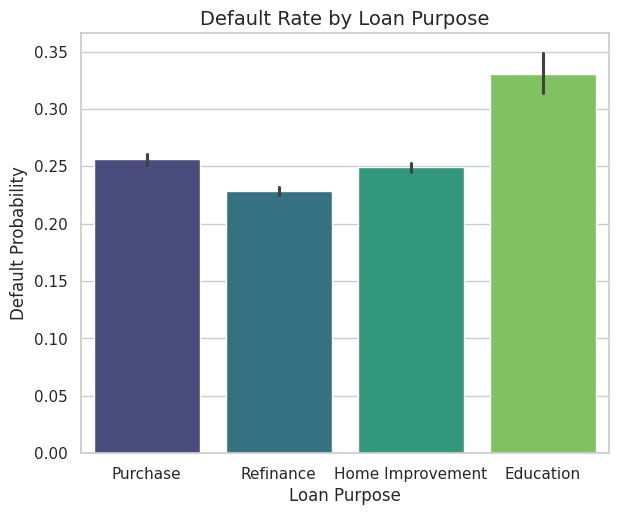

In [ ]:
# 1. Bar Chart — Default Rate by Loan Purpose

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15,12))

plt.subplot(2,2,1)
ax=sns.barplot(data=df, x='loan_purpose', y='status',palette='viridis')
plt.title('Default Rate by Loan Purpose', fontsize=14)
plt.ylabel('Default Probability')
plt.xlabel('Loan Purpose')
ax.set_xticklabels(['Purchase', 'Refinance', 'Home Improvement', 'Education'])

## Visualization Analysis: Distribution of Loan Types

This pie chart illustrates the proportion of each loan type within the lending portfolio.

Analyzing loan type distribution helps identify:
- which loan categories are most common
- how lending activity is distributed across loan segments
- potential concentration areas within the portfolio

A higher concentration of a particular loan type may indicate:
- stronger borrower demand
- lender preference for specific loan programs
- increased financial exposure within certain lending categories

Understanding portfolio distribution is important because heavy reliance on a single loan category may increase concentration risk if economic conditions negatively impact that segment.

The chart also provides insight into the overall composition of the lending portfolio and supports strategic lending and risk management decisions.

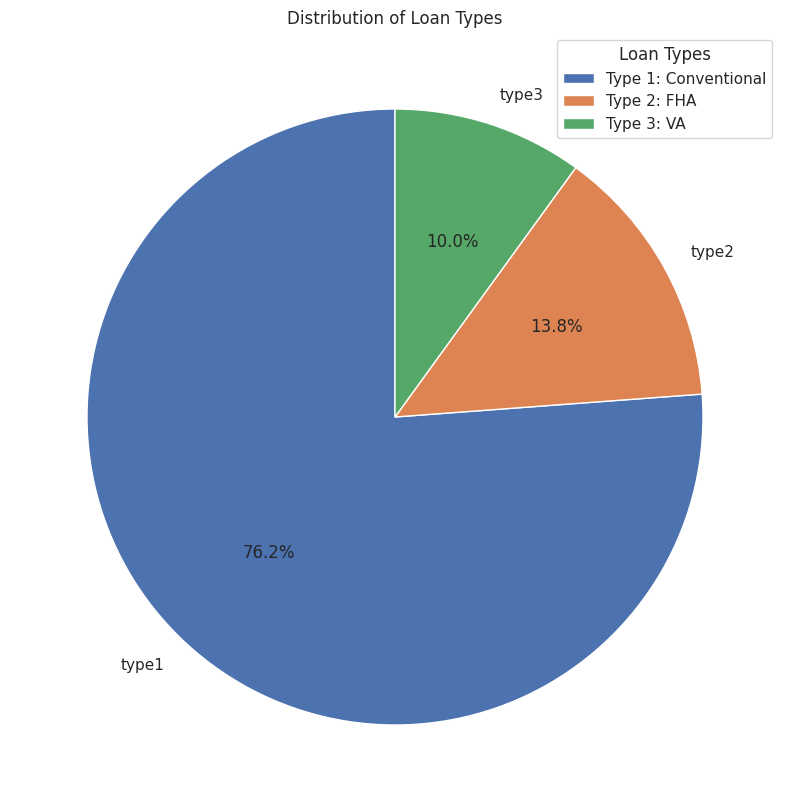

In [ ]:
# 2. Pie Chart — Loan Distribution by Status

plt.figure(figsize=(10,10))

ax = df['loan_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

# Improved legend labels
plt.legend(
    labels=[
        'Type 1: Conventional',
        'Type 2: FHA',
        'Type 3: VA'
    ],
    loc="best",
    title="Loan Types"
)

plt.title("Distribution of Loan Types")
plt.ylabel("")

plt.show()

## Visualization Analysis: Debt-to-Income Ratio by Loan Purpose

This box plot compares debt-to-income (DTI) ratios across different loan purposes to better understand borrower financial obligations within each lending category.

The visualization helps identify:
- differences in borrower debt levels
- variability in financial risk across loan purposes
- potential outliers within the dataset

Debt-to-income ratio is an important financial metric because it measures how much of a borrower’s income is already committed to existing debt obligations.

Higher DTI ratios may indicate:
- increased financial strain
- reduced repayment flexibility
- elevated lending risk

The presence of outliers suggests that some borrowers carry significantly higher debt burdens than the typical applicant, which may require additional risk assessment during the lending process.

This analysis supports financial institutions in evaluating borrower affordability and understanding how financial risk may vary across different loan purposes.

/tmp/ipykernel_16318/2332467035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(data=df, x='loan_purpose', y='dtir1', palette='Set2')
/tmp/ipykernel_16318/2332467035.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Purchase', 'Refinance', 'Home Improvement', 'Education'])


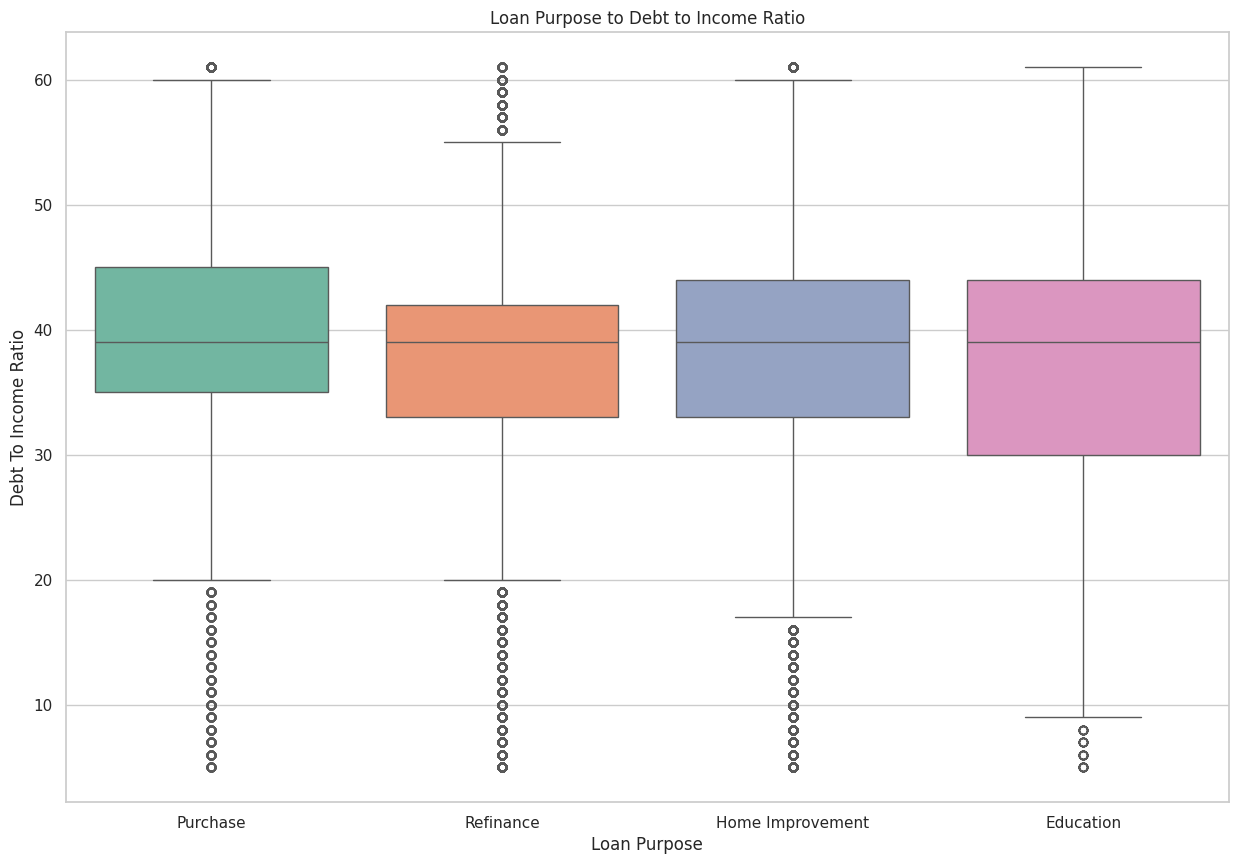

In [ ]:
#3. Box Plot — Loan Amount Spread (Outliers)
plt.figure(figsize=(15,10))
ax=sns.boxplot(data=df, x='loan_purpose', y='dtir1', palette='Set2')
plt.title("Loan Purpose to Debt to Income Ratio")
plt.xlabel('Loan Purpose')
plt.ylabel('Debt To Income Ratio')
ax.set_xticklabels(['Purchase', 'Refinance', 'Home Improvement', 'Education'])
plt.show()

## Outlier Detection Using Z-Score

Z-score analysis was used to identify unusually high or low values within key financial variables.

Observations with a Z-score greater than 3 were considered potential outliers.

Detecting outliers is important because extreme financial values can:
- influence lending risk analysis
- affect predictive model performance
- indicate unusual borrower or loan behavior

This analysis supports more reliable financial modeling and risk evaluation.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import zscore

In [ ]:
numeric_features = [
    'loan_amount',
    'income',
    'property_value',
    'credit_score',
    'rate_of_interest'
]

zscore_df = df[numeric_features].copy()
z_scores = np.abs(zscore(zscore_df, nan_policy='omit'))
outliers = z_scores > 3

outlier_counts = pd.DataFrame({
    'Feature': numeric_features,
    'Outlier Count': outliers.sum(axis=0)
})

outlier_counts

,Feature,Outlier Count
0,loan_amount,1348
1,income,1484
2,property_value,2225
3,credit_score,0
4,rate_of_interest,1370


## Z-Score Outlier Detection Analysis

This visualization shows the number of statistical outliers detected across key financial variables using the Z-score method.

A Z-score measures how far a value deviates from the dataset mean in terms of standard deviations. Observations with an absolute Z-score greater than 3 were classified as potential outliers.

The analysis reveals that:

- **Property value** contains the highest number of outliers, indicating the presence of unusually high-value properties within the lending portfolio.
- **Income** and **loan amount** also show a significant number of extreme observations, suggesting variability in borrower financial capacity and lending exposure.
- **Rate of interest** contains moderate outlier activity, which may reflect higher-risk lending scenarios or non-standard loan conditions.
- **Credit score** shows relatively few extreme outliers, indicating that borrower credit scores are more consistently distributed across the dataset.

Outlier detection is important because extreme financial values can:
- influence predictive model accuracy
- skew statistical analysis
- indicate elevated lending risk
- reveal unusual borrower or loan behavior patterns

This analysis supports stronger data quality assessment and helps identify areas that may require additional investigation during financial risk modeling.

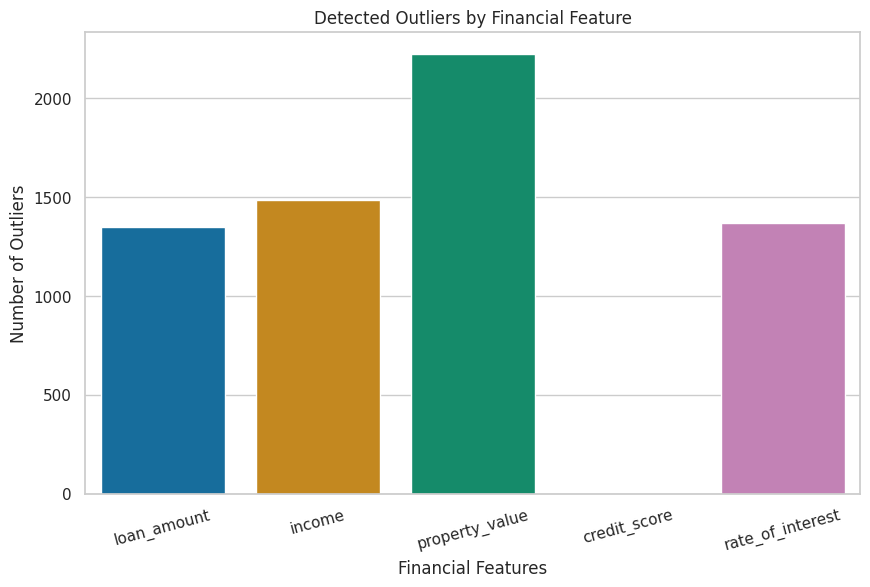

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=outlier_counts,
    x='Feature',
    y='Outlier Count',
    hue='Feature',
    palette='colorblind',
    legend=False
)

plt.title("Detected Outliers by Financial Feature")
plt.xlabel("Financial Features")
plt.ylabel("Number of Outliers")

plt.xticks(rotation=15)

plt.show()

## Correlation Matrix Analysis

A correlation matrix is used to measure the strength and direction of relationships between numerical variables within the dataset.

Correlation values help identify whether variables:
- increase together (positive correlation)
- move in opposite directions (negative correlation)
- have little or no relationship

This analysis provides insight into how financial and borrower-related variables may interact, including relationships between:
- loan amount
- income
- credit score
- interest rates
- debt-to-income ratios
- property value

Understanding these relationships is important because strongly correlated variables may influence:
- lending risk
- borrower repayment behavior
- predictive model performance
- financial decision-making strategies

Correlation analysis also supports feature selection for machine learning models by identifying variables that may have stronger predictive value.

In [ ]:
#Compute correlation matrix for numeric columns
df.corr(numeric_only=True)

,id,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,status,dtir1,month,quarter,year
id,1.000000,-0.000459,0.000301,0.001642,-0.005224,-0.003901,0.000021,0.001573,-0.000513,-0.005082,0.001484,-0.007151,0.002964,0.002366,NaN
loan_amount,-0.000459,1.000000,-0.124083,-0.309674,0.057311,0.174589,0.685558,0.441945,0.004683,0.036108,-0.034686,0.014644,-0.002181,-0.002281,NaN
rate_of_interest,0.000301,-0.124083,1.000000,0.616585,-0.069616,0.181743,-0.104424,-0.015872,-0.000855,-0.001851,-0.043715,0.031280,0.000085,0.000157,NaN
interest_rate_spread,0.001642,-0.309674,0.616585,1.000000,0.036632,-0.137492,-0.286994,-0.100756,-0.001870,0.036246,-0.046264,0.049914,0.004330,0.004333,NaN
upfront_charges,-0.005224,0.057311,-0.069616,0.036632,1.000000,-0.046575,0.049753,0.026611,-0.001273,-0.031927,-0.094736,-0.013643,-0.004898,-0.004777,NaN
term,-0.003901,0.174589,0.181743,-0.137492,-0.046575,1.000000,0.042155,-0.057837,-0.002552,0.100362,-0.000662,0.106942,-0.005058,-0.005129,NaN
property_value,0.000021,0.685558,-0.104424,-0.286994,0.049753,0.042155,1.000000,0.389507,0.002581,-0.213621,-0.079112,-0.059838,-0.002085,-0.002820,NaN
income,0.001573,0.441945,-0.015872,-0.100756,0.026611,-0.057837,0.389507,1.000000,0.001590,-0.033925,-0.059832,-0.254796,-0.000043,-0.001440,NaN
credit_score,-0.000513,0.004683,-0.000855,-0.001870,-0.001273,-0.002552,0.002581,0.001590,1.000000,-0.005490,0.003173,-0.000182,0.000338,0.001338,NaN
ltv,-0.005082,0.036108,-0.001851,0.036246,-0.031927,0.100362,-0.213621,-0.033925,-0.005490,1.000000,0.041862,0.075160,-0.001916,-0.002165,NaN


## Correlation Analysis: Relationships with Borrower Income

This analysis examines how borrower income correlates with other numerical variables within the dataset.

By sorting correlations relative to income, the analysis helps identify which financial factors appear to have stronger positive or negative relationships with borrower earnings.

Understanding income relationships is important because income is often a key factor in:
- loan eligibility assessment
- lending capacity evaluation
- repayment ability analysis
- financial risk assessment

Variables with stronger correlations to income may provide insight into:
- borrower financial stability
- loan affordability patterns
- lending behavior trends
- potential predictors for risk modeling

This analysis also supports feature selection for predictive analytics by highlighting variables that may have meaningful relationships with borrower income levels.

In [ ]:
#Sort correlations with income
corr= df.select_dtypes(include=[np.number])
corr.corr()['income'].sort_values()

,income
dtir1,-0.254796
interest_rate_spread,-0.100756
status,-0.059832
term,-0.057837
ltv,-0.033925
rate_of_interest,-0.015872
quarter,-0.001440
month,-0.000043
id,0.001573
credit_score,0.001590


## Correlation Analysis: Financial Relationships Within the Loan Portfolio

This analysis explores relationships between key financial variables within the lending dataset using correlation analysis and regression visualization techniques.

The correlation analysis identified several important relationships:

- Loan amount shows a positive relationship with property value
- Loan amount also demonstrates a positive relationship with borrower income
- Loan amount has a negative relationship with interest rate spread
- Rate of interest is positively related to interest rate spread
- Debt-to-income ratio (`dtir1`) shows a relationship with borrower income
- Loan-to-value ratio (`ltv`) is associated with property value

The regression plot between property value and loan amount demonstrates a positive relationship, indicating that borrowers purchasing higher-value properties generally receive larger loans.

Most borrowers are concentrated within lower-to-mid property value ranges, suggesting that the majority of lending activity occurs within more typical residential financing segments.

Although the overall trend shows a positive correlation, the wide spread of data points indicates that property value alone does not fully determine loan size. Other borrower-related factors such as income, credit score, debt-to-income ratio, and lending conditions likely also influence lending decisions.

Several outliers are visible within the dataset, representing unusually large property values or loan amounts. These may reflect unique lending scenarios, luxury property financing, or higher-risk borrower profiles.

Negative correlations involving interest rate spread may indicate that borrowers with stronger financial profiles or larger loans receive more favorable lending conditions.

Understanding these relationships is important because these variables play a significant role in:
- lending eligibility
- risk assessment
- borrower affordability evaluation
- pricing strategies
- predictive modeling

Correlation analysis helps financial institutions identify patterns within borrower behavior and better understand how different financial factors interact within the lending portfolio.




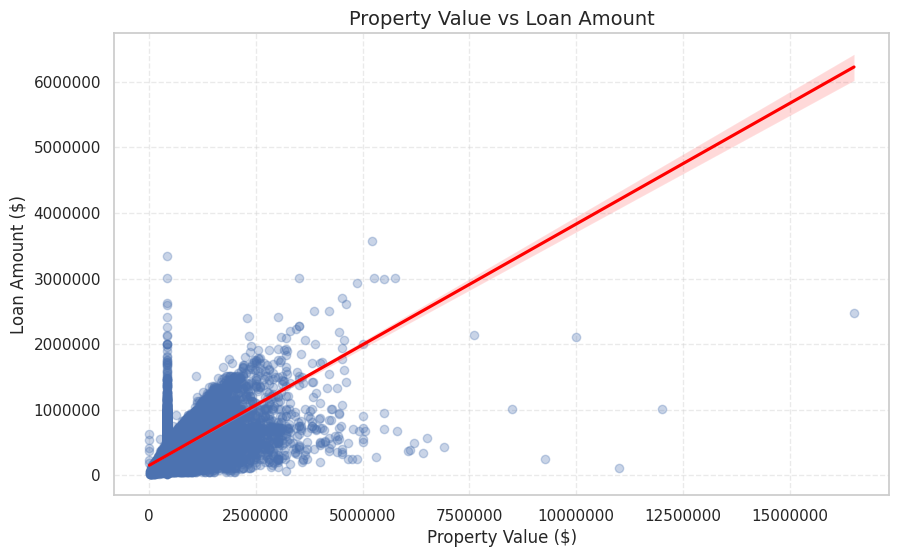

In [ ]:
# Correlation between property value and loan amount

corr = df[['property_value', 'loan_amount']].corr()

plt.figure(figsize=(10,6))

ax = sns.regplot(
    x='property_value',
    y='loan_amount',
    data=df,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

# Remove scientific notation
ax.ticklabel_format(style='plain', axis='both')

plt.title("Property Value vs Loan Amount", fontsize=14)
plt.xlabel("Property Value ($)")
plt.ylabel("Loan Amount ($)")

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Regression Analysis: Borrower Income and Loan Amount

This regression plot examines the relationship between borrower income and loan amount within the lending dataset.

The upward regression trend suggests a positive relationship, indicating that borrowers with higher income levels generally tend to receive larger loans.

Most borrowers are concentrated within lower-to-middle income ranges, reflecting the primary lending activity within the portfolio. However, the wide spread of data points shows that income alone does not fully determine loan size.

Borrowers with similar income levels may still receive significantly different loan amounts due to additional lending factors such as:
- property value
- credit score
- debt-to-income ratio
- loan type
- interest rates

Several outliers are also visible, representing unusually high-income borrowers or unique lending scenarios.

This analysis highlights the importance of considering multiple financial variables when evaluating lending decisions and borrower risk profiles.

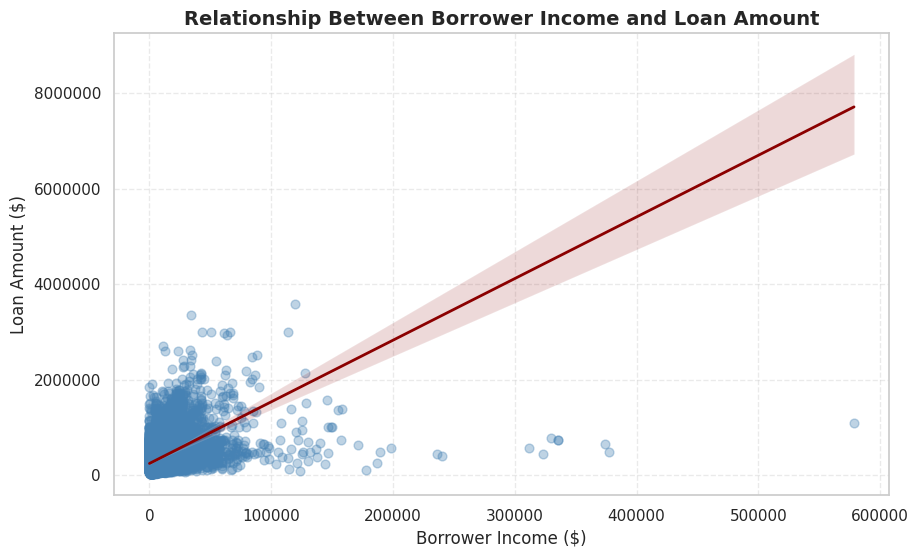

In [ ]:
# Regression plot to visualize the relationship between income and loan amount

plt.figure(figsize=(10,6))

ax = sns.regplot(
    data=df,
    x='income',
    y='loan_amount',
    scatter_kws={
        'alpha':0.35,
        'color':'steelblue',
        's':40
    },
    line_kws={
        'color':'darkred',
        'linewidth':2
    }
)

# Remove scientific notation
ax.ticklabel_format(style='plain', axis='both')

plt.title(
    "Relationship Between Borrower Income and Loan Amount",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Borrower Income ($)", fontsize=12)
plt.ylabel("Loan Amount ($)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Regression Analysis: Loan Amount and Interest Rate Spread

This regression plot explores the relationship between loan amount and interest rate spread within the lending portfolio.

The downward regression trend suggests a negative relationship, indicating that borrowers receiving larger loans may generally receive lower interest rate spreads.

This pattern may reflect:
- stronger borrower financial profiles
- lower perceived lending risk
- preferential lending terms for higher-value loans

Most borrowers are concentrated within lower-to-middle loan amount ranges, representing the primary lending activity within the dataset.

The wide spread of data points also indicates that loan amount alone does not fully determine interest rate spread. Additional financial variables such as:
- credit score
- borrower income
- debt-to-income ratio
- property value
- loan type

may also influence lending conditions and pricing decisions.

Several outliers are visible within the dataset, representing unusual lending scenarios or borrowers with atypical financing conditions.

This analysis demonstrates how pricing and lending risk may vary across different borrower and loan profiles within the portfolio.

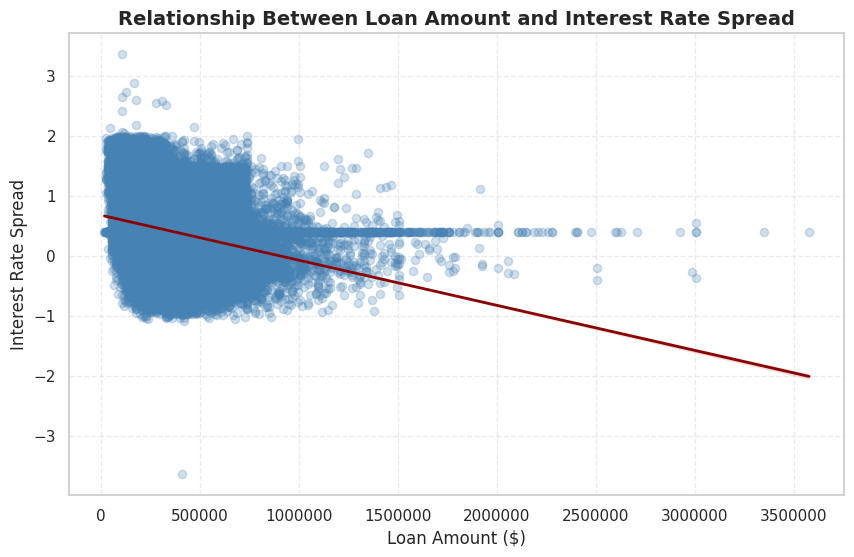

In [ ]:
# Regression plot to visualize the relationship between loan amount and interest rate spread

plt.figure(figsize=(10,6))

ax = sns.regplot(
    data=df,
    x='loan_amount',
    y='interest_rate_spread',
    scatter_kws={
        'alpha':0.25,
        'color':'steelblue',
        's':35
    },
    line_kws={
        'color':'darkred',
        'linewidth':2
    }
)

# Remove scientific notation
ax.ticklabel_format(style='plain', axis='x')

plt.title(
    "Relationship Between Loan Amount and Interest Rate Spread",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Loan Amount ($)", fontsize=12)
plt.ylabel("Interest Rate Spread", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()


## Regression Analysis: Property Value and Interest Rate Spread

This regression plot explores the relationship between property value and interest rate spread within the lending portfolio.

The downward regression trend suggests a negative relationship, indicating that borrowers purchasing higher-value properties may generally receive lower interest rate spreads.

This pattern may suggest that stronger collateral value is associated with more favorable lending conditions and potentially lower perceived lending risk.

Most borrowers are concentrated within lower-to-middle property value ranges, reflecting the primary lending activity within the dataset.

The wide spread of data points indicates that property value alone does not fully determine interest rate spread. Other financial and borrower-related variables such as:
- borrower income
- credit score
- debt-to-income ratio
- loan type
- overall lending risk

may also influence pricing decisions and loan terms.

Several outliers are visible within the dataset, representing unusually high property values or atypical financing scenarios.

This analysis highlights how collateral value may influence lending conditions while also demonstrating the complexity of financial risk assessment within mortgage lending.

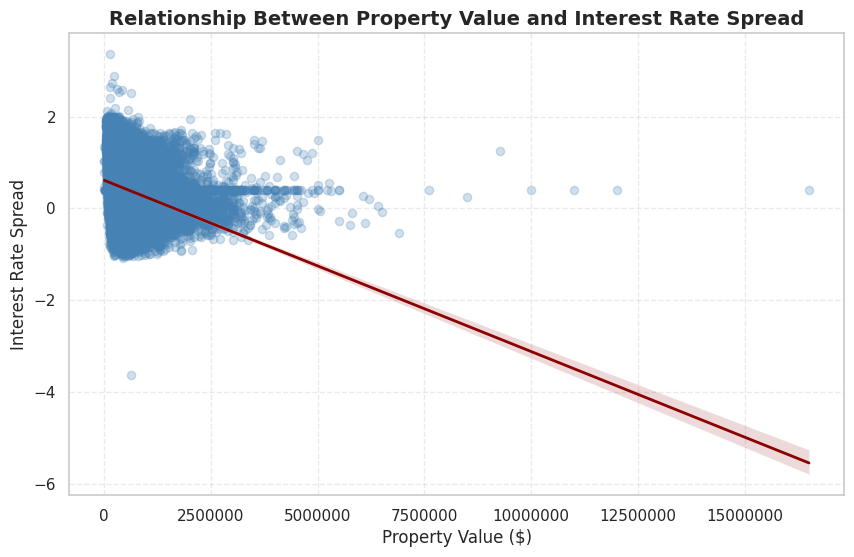

In [ ]:
# Regression plot to visualize the relationship between property value and interest rate spread

plt.figure(figsize=(10,6))

ax = sns.regplot(
    data=df,
    x='property_value',
    y='interest_rate_spread',
    scatter_kws={
        'alpha':0.25,
        'color':'steelblue',
        's':35
    },
    line_kws={
        'color':'darkred',
        'linewidth':2
    }
)

# Remove scientific notation
ax.ticklabel_format(style='plain', axis='x')

plt.title(
    "Relationship Between Property Value and Interest Rate Spread",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Property Value ($)", fontsize=12)
plt.ylabel("Interest Rate Spread", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Linear Regression Modeling: Predicting Loan Amount from Borrower Income

A linear regression model is developed to examine the relationship between borrower income and loan amount.

In this analysis:
- borrower income is used as the independent variable (`X`)
- loan amount is used as the target variable (`Y`)

The model attempts to determine whether income can help predict loan amount within the lending dataset.

The R² (R-squared) score is then calculated to evaluate how well the model explains the variation in loan amounts.

An R² value closer to:
- `1` indicates a stronger predictive relationship
- `0` indicates a weaker relationship with limited predictive power

This analysis helps assess whether borrower income alone is a meaningful predictor of loan size or whether additional financial variables may be needed to improve predictive performance.

In [ ]:
X = df[['income']]
Y = df['loan_amount']
lm = LinearRegression()
lm.fit(X,Y)
lm.score(X, Y)

0.1953154890750176

## Multiple Linear Regression Modeling: Predicting Loan Amount

A multiple linear regression model is developed to predict loan amount using several borrower and lending-related financial variables.

The selected features include:
- borrower income
- credit score
- loan status
- interest rate
- loan-to-value ratio (`ltv`)
- debt-to-income ratio (`dtir1`)

Unlike simple linear regression, which uses only one predictor, multiple linear regression evaluates how several financial variables collectively influence loan amount.

The model is trained using the selected features, and the R² (R-squared) score is calculated to measure how effectively the model explains variation in loan amounts.

A higher R² value suggests that the selected variables provide stronger predictive power and may better capture the complexity of lending behavior within the dataset.

This analysis demonstrates how multiple financial indicators can be combined to support:
- predictive analytics
- lending risk assessment
- borrower evaluation
- data-driven financial decision-making


In [ ]:
features=["income", "credit_score","status", "rate_of_interest", "ltv", "dtir1" ]
lm2=LinearRegression()
lm2.fit(df[features], df['loan_amount'])
print(lm2.score(df[features], df['loan_amount']))

0.2296019573960163


## Pipeline Modeling: Polynomial Regression Analysis

To improve predictive performance, a machine learning pipeline is created using data preprocessing and polynomial regression techniques.

The pipeline combines several steps into a single workflow:
- feature scaling using `StandardScaler()`
- polynomial feature transformation using `PolynomialFeatures()`
- linear regression modeling using `LinearRegression()`

Polynomial feature expansion allows the model to capture more complex and non-linear relationships between financial variables and loan amount.

The model is then evaluated using the R² (R-squared) score to measure how effectively the pipeline explains variation in loan amounts.

Comparing the pipeline model to the earlier linear regression models helps determine whether more advanced feature engineering improves predictive performance.

This analysis demonstrates how machine learning pipelines can support:
- predictive analytics
- financial forecasting
- lending behavior analysis
- model optimization
- scalable data science workflows

In [ ]:
Input=[('scale',StandardScaler()),('polynomial', PolynomialFeatures(include_bias=False)),('model',LinearRegression())]
pipe=Pipeline(Input)
pipe.fit(df[features], df['loan_amount'])
print(pipe.score(df[features],df['loan_amount']))

0.3531793062992208


## Train-Test Split for Model Evaluation

To evaluate model performance more effectively, the dataset is divided into training and testing subsets.

The selected financial features include:
- borrower income
- credit score
- loan status
- interest rate
- loan-to-value ratio (`ltv`)
- debt-to-income ratio (`dtir1`)

The dataset split allows the model to:
- train on one portion of the data
- test predictive performance on unseen data

This process is important because it helps assess how well the model may generalize to new borrower records rather than simply memorizing the training dataset.

A portion of the data is reserved for testing (`15%`) while the remaining records are used for training the model.

Using separate training and testing datasets supports:
- more reliable model evaluation
- reduced overfitting risk
- improved predictive analysis practices
- stronger machine learning validation workflows

The earlier polynomial regression pipeline demonstrated stronger R² performance than the basic linear regression model, suggesting that relationships between loan amount and borrower financial variables may involve more complex non-linear patterns.

However, the predictive models developed in this project should be interpreted as exploratory analytical models rather than final production-ready lending models.

In [ ]:
features=["income", "credit_score","status", "rate_of_interest", "ltv", "dtir1" ]
X = df[features]
Y = df['loan_amount']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 21598
number of training samples: 122385


## Ridge Regression Modeling and Regularization

To further improve model stability and reduce the risk of overfitting, a Ridge Regression model is developed using the training dataset.

Ridge Regression is a regularized version of linear regression that introduces a penalty term to reduce the impact of excessively large model coefficients.

This technique is especially useful when:
- multiple financial variables are correlated
- models become overly sensitive to training data
- prediction stability needs improvement

The model is trained using the selected borrower and lending-related financial features, and predictive performance is evaluated using the R² (R-squared) score on the testing dataset.

The regularization parameter (`alpha=0.1`) controls the strength of the penalty applied to the model coefficients.

Using Ridge Regression helps:
- reduce model complexity
- improve generalization on unseen data
- minimize overfitting risk
- support more stable predictive performance

This analysis demonstrates how regularization techniques can strengthen machine learning models used in financial analytics and lending risk assessment workflows.

In [ ]:
Ridge_model= Ridge(alpha=0.1)
Ridge_model.fit(x_train, y_train)
print(Ridge_model.score(x_test, y_test))

0.22648296176269067


## Polynomial Ridge Regression Modeling

To capture more complex relationships within the lending dataset, a second-order polynomial transformation is applied to both the training and testing data before fitting a Ridge Regression model.

Polynomial transformation expands the original financial features by creating interaction and squared terms, allowing the model to detect non-linear relationships between borrower variables and loan amount.

After transforming the data:
- a Ridge Regression model is trained using the polynomial features
- the regularization parameter (`alpha=0.1`) is applied to help reduce overfitting
- model performance is evaluated using the R² (R-squared) score on the testing dataset

Combining polynomial feature engineering with Ridge Regression helps:
- capture more complex financial patterns
- improve predictive flexibility
- stabilize model performance
- reduce sensitivity to noisy data

This approach demonstrates how advanced machine learning techniques can improve predictive analytics within financial and lending-related datasets.

Comparing the R² performance of this model against earlier regression models helps determine whether introducing non-linear relationships improves the model’s ability to explain variation in loan amounts.

In [ ]:
pr=PolynomialFeatures(degree=2)
x_train_pr= pr.fit_transform(x_train)
x_test_pr= pr.fit_transform(x_test)
Ridge_model1=Ridge(alpha=0.1)
Ridge_model1.fit(x_train_pr, y_train)
print(Ridge_model1.score(x_test_pr, y_test))

0.3284475726042131


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.6937e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


### Business Question

How do loan defaults vary across different loan purposes?

## Visualization Analysis: Loan Defaults by Loan Purpose

This visualization examines the number of loan defaults across different loan purposes to identify lending categories associated with higher default activity.

Analyzing default frequency by loan purpose helps reveal:
- potential differences in borrower financial risk
- lending segments with elevated repayment challenges
- patterns within borrower financing behavior

Higher concentrations of defaults within specific loan categories may indicate:
- increased borrower financial strain
- elevated lending risk
- differences in repayment stability across loan purposes

Understanding these patterns can help financial institutions:
- strengthen underwriting strategies
- improve risk assessment models
- identify higher-risk lending categories
- support more informed lending and portfolio management decisions

/tmp/ipykernel_16318/779435470.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_16318/779435470.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


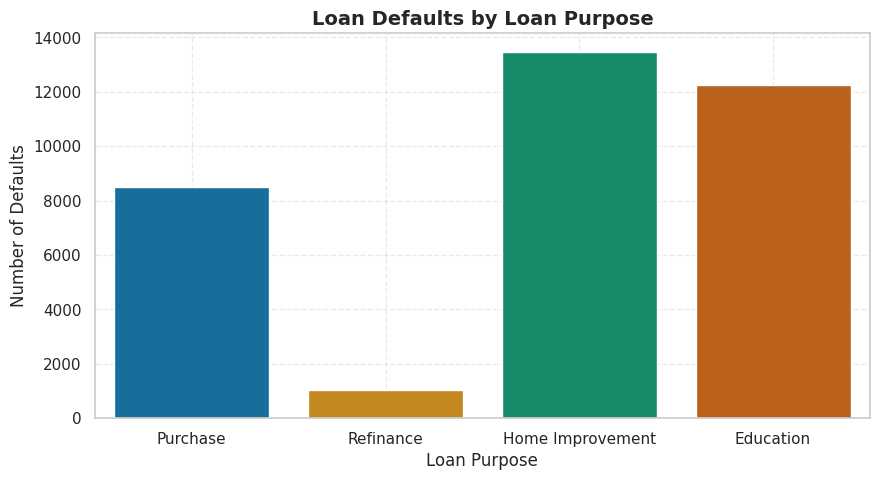

In [ ]:
# Default counts by loan purpose

default_counts = (
    df[df['status'] == 1]
    .groupby('loan_purpose')
    .size()
    .reset_index(name='default_count')
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=default_counts,
    x='loan_purpose',
    y='default_count',
    palette='colorblind'
)

plt.title(
    "Loan Defaults by Loan Purpose",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Loan Purpose", fontsize=12)
plt.ylabel("Number of Defaults", fontsize=12)

ax.set_xticklabels([
    'Purchase',
    'Refinance',
    'Home Improvement',
    'Education'
])

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

### Business Question

How do borrower risk characteristics differ between government-backed and conventional loan types?

## Comparative Analysis: Government-Backed vs Conventional Loans

This analysis compares borrower and lending characteristics across different loan types, including conventional and government-backed loan programs.

The grouped analysis evaluates:
- average credit score
- average default rate
- median loan amount

for each loan category.

Comparing these financial indicators helps identify whether different loan programs may attract borrowers with varying financial profiles or lending risk characteristics.

Government-backed loans are often designed to improve access to financing for borrowers who may not qualify for traditional lending programs. As a result, differences in:
- credit score
- default behavior
- loan size

may reveal important patterns within the lending portfolio.

This analysis supports a better understanding of how lending risk and borrower characteristics vary across loan categories.

In [ ]:
#sns.boxplot(y='credit_score',x='loan_type', data=df)
# Boxplot was not used because the credit score distributions appeared very similar across loan types.
analysis = df.groupby('loan_type').agg({
    'credit_score':'mean',
    'status':'mean',
    'loan_amount':'median'
})
print(analysis)

           credit_score    status  loan_amount
loan_type                                     
type1        699.940772  0.227068     316500.0
type2        699.227768  0.340547     226500.0
type3        698.443440  0.249061     296500.0


## Pre-Approval Analysis by Loan Type

This analysis examines the percentage distribution of pre-approved and non-pre-approved loans across different loan categories.

By calculating pre-approval rates for each loan type, the analysis helps identify:
- differences in lending approval patterns
- variations in underwriting practices
- potential borrower qualification trends across loan programs

Comparing pre-approval distributions may provide insight into:
- how different loan programs are processed
- whether certain loan categories are associated with higher pre-approval activity
- differences in borrower eligibility characteristics

Government-backed and conventional loan programs often serve different borrower segments, so analyzing pre-approval patterns can help reveal variations in:
- lending accessibility
- borrower financial profiles
- approval workflows

This analysis supports a broader understanding of how lending institutions manage approval processes across different loan types within the portfolio.

In [ ]:
#Calculating the percentage of pre-approvals for each loan type
#This shows: Out of all Type 1 loans, what % got the 'pre' vs 'nopre'
pre_app_check= pd.crosstab(df['loan_type'], df['approv_in_adv'], normalize='index')*100

#Renaming types for clarity
pre_app_check.index=['Type1(Conventional)', 'Type 2(FHA)', 'Type 3(VA)']
print("Pre-Approval Rates by Loan Type (%):")
print(pre_app_check)

Pre-Approval Rates by Loan Type (%):
approv_in_adv            nopre        pre
Type1(Conventional)  84.101227  15.898773
Type 2(FHA)          82.952548  17.047452
Type 3(VA)           85.320718  14.679282


## Visualization Analysis: Pre-Approval Distribution by Loan Type

This stacked bar chart compares the percentage distribution of pre-approved and non-pre-approved applications across different loan types.

The visualization helps identify:
- differences in pre-approval activity between loan programs
- potential variations in borrower qualification patterns
- trends in lending approval workflows

The results suggest that the majority of applications across all loan categories were not pre-approved prior to final loan processing. However, small variations between loan types may indicate differences in:
- borrower financial profiles
- underwriting requirements
- lending program structures

Comparing government-backed and conventional loan categories can provide insight into how approval processes may differ across lending programs.

This analysis supports a broader understanding of lending accessibility, borrower qualification trends, and risk management practices within the lending portfolio.

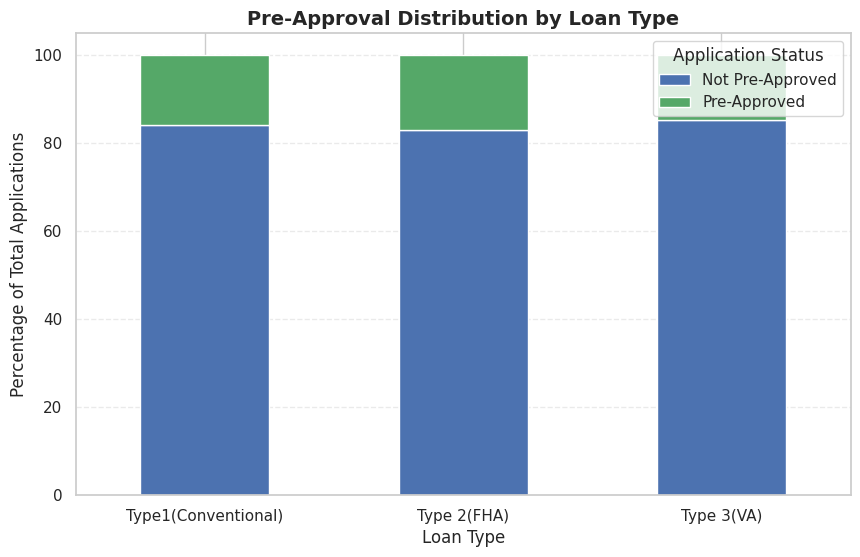

In [ ]:
# Stacked bar chart: Pre-approval distribution by loan type

ax = pre_app_check.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['#4C72B0', '#55A868']   # Accessible blue/green palette
)

plt.title(
    "Pre-Approval Distribution by Loan Type",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Percentage of Total Applications", fontsize=12)
plt.xlabel("Loan Type", fontsize=12)

# Cleaner legend labels
plt.legend(
    ['Not Pre-Approved', 'Pre-Approved'],
    title='Application Status'
)

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

### Analysis Question

How do credit scores relate to loan amounts and loan default risk among borrowers?

Does borrower credit score appear to influence loan amount distribution and default risk patterns?

### Business Insight: Credit Score, Loan Amount, and Default Risk

This visualization explores the relationship between borrower credit scores, loan amounts, and loan default outcomes.

Borrowers with higher credit scores generally appear across a wider range of loan amounts, which may suggest that stronger creditworthiness provides access to larger lending opportunities.

The chart also highlights patterns in loan default behavior. Defaulted loans appear more concentrated among borrowers with lower-to-moderate credit scores, indicating that credit score may play an important role in lending risk assessment.

However, the overlap between groups suggests that credit score alone is not sufficient to fully predict loan default outcomes. Additional financial factors such as income, debt-to-income ratio, and interest rates may also influence borrower repayment behavior.

This analysis supports the importance of multi-factor risk evaluation in financial lending decisions.

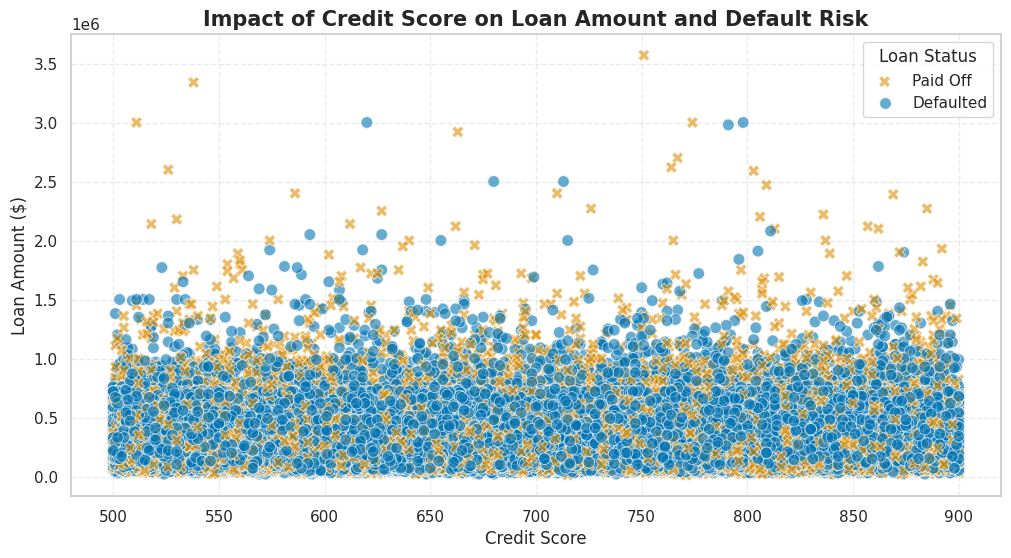

In [ ]:
plt.figure(figsize=(12,6))

# Accessible scatter plot using colorblind-friendly palette
sns.scatterplot(
    data=df,
    x='credit_score',
    y='loan_amount',
    hue='status',
    style='status',                 # Adds different marker shapes
    alpha=0.6,                      # Better visibility
    s=70,                           # Larger point size
    palette='colorblind'            # Accessibility-friendly palette
)

plt.title(
    "Impact of Credit Score on Loan Amount and Default Risk",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Credit Score", fontsize=12)
plt.ylabel("Loan Amount ($)", fontsize=12)

plt.legend(
    title="Loan Status",
    labels=['Paid Off', 'Defaulted'],
    loc='upper right'
)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Comparative Analysis: Residential vs Commercial Lending Risk

This analysis compares borrower credit characteristics and loan default behavior between residential and commercial lending categories.

The results show that average credit scores are very similar across both groups:
- Commercial loans (`b/c`) average approximately 699
- Residential loans (`nob/c`) average approximately 700

Despite the similarity in borrower credit scores, commercial loans demonstrated a noticeably higher average default rate compared to residential loans.

This suggests that:
- credit score alone may not fully explain lending risk differences
- commercial lending may involve additional financial complexity or repayment risk
- other variables beyond borrower creditworthiness may influence commercial loan performance

The analysis highlights the importance of evaluating multiple financial and lending factors when assessing borrower risk within different loan segments.

Understanding these differences can help financial institutions:
- improve risk assessment strategies
- strengthen underwriting practices
- identify higher-risk lending categories
- support more informed portfolio management decisions

In [ ]:
# Comparing Credit Score and Default Rate by Property Usage
usage_comparison = df.groupby('business_or_commercial').agg({
    'credit_score': ['mean', 'min', 'max', 'std'],
    'status': 'mean'
})

print("Residential vs. Commercial Comparison:")
print(usage_comparison)

Residential vs. Commercial Comparison:
                       credit_score                          status
                               mean  min  max         std      mean
business_or_commercial                                             
b/c                      699.227768  500  900  116.497616  0.340547
nob/c                    699.767297  500  900  115.793695  0.229616


## Business Insight: Residential vs Commercial Credit Risk

This visualization compares credit score distributions between residential and commercial loan categories.

The box plots show that both residential and commercial borrowers have very similar credit score distributions, including comparable median scores and overall score ranges.

However, earlier analysis revealed that commercial loans demonstrated a higher average default rate despite these similar credit score patterns.

This suggests that credit score alone may not fully explain differences in lending risk between residential and commercial loans. Additional financial, operational, or lending-related factors may contribute to the higher default activity observed within commercial lending segments.

The analysis highlights the importance of evaluating multiple borrower and loan characteristics when assessing financial risk across different lending categories.

/tmp/ipykernel_16318/431938706.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


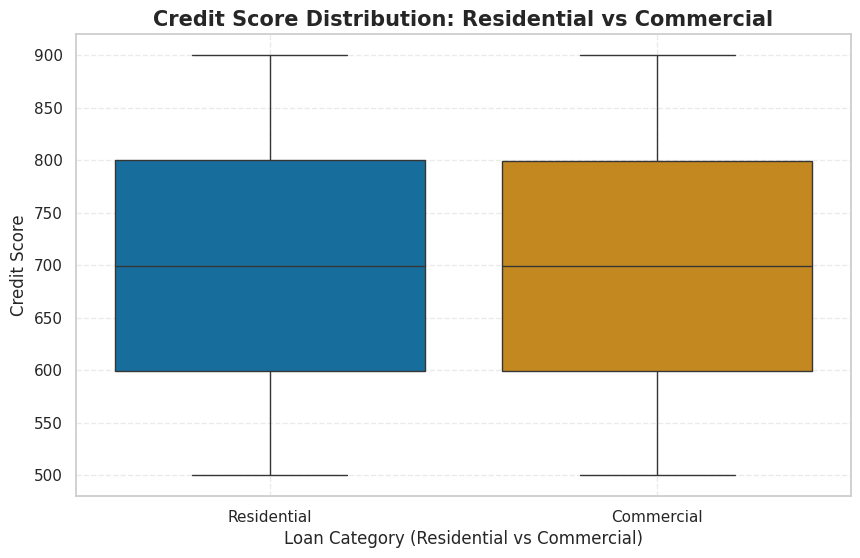

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=df,
    x='business_or_commercial',
    y='credit_score',
    hue='business_or_commercial',
    palette='colorblind',
    legend=False
)

plt.title(
    "Credit Score Distribution: Residential vs Commercial",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    "Loan Category (Residential vs Commercial)",
    fontsize=12
)

plt.ylabel("Credit Score", fontsize=12)

# Cleaner x-axis labels
ax.set_xticklabels([
    'Residential',
    'Commercial'
])

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

## Business Insight: Credit Score Distribution

The box plot shows that most borrowers fall within a moderate-to-high credit score range, with the median centered around approximately 700.

The relatively wide distribution of scores suggests variability in borrower creditworthiness across the lending portfolio. Most borrowers are concentrated between the mid-to-upper credit score ranges, indicating generally moderate financial stability among applicants.

Unlike some of the other financial variables in the dataset, the credit score distribution shows relatively few extreme outliers, suggesting that borrower credit profiles are fairly consistent overall.

Higher credit scores are generally associated with lower lending risk, while lower scores may indicate increased repayment risk and reduced financial flexibility.

This analysis highlights the importance of credit score as a key factor in:
- lending eligibility
- borrower risk assessment
- underwriting decisions
- loan pricing strategies

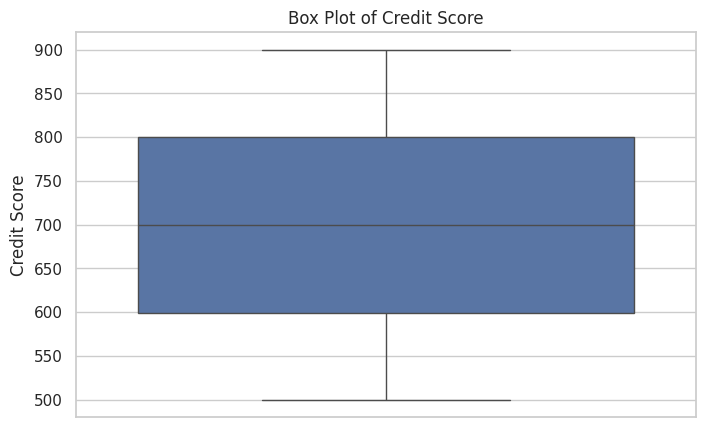

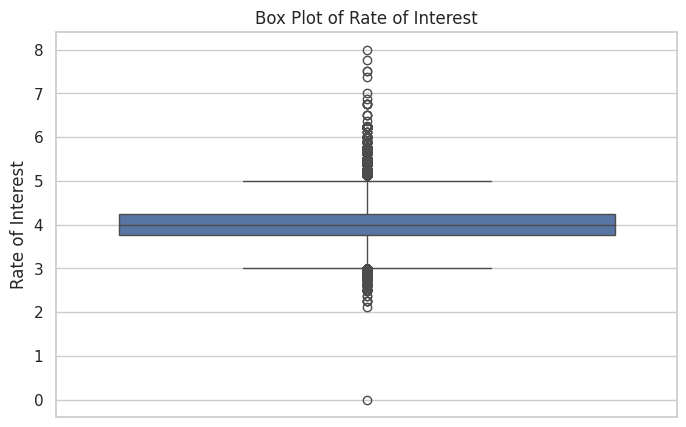

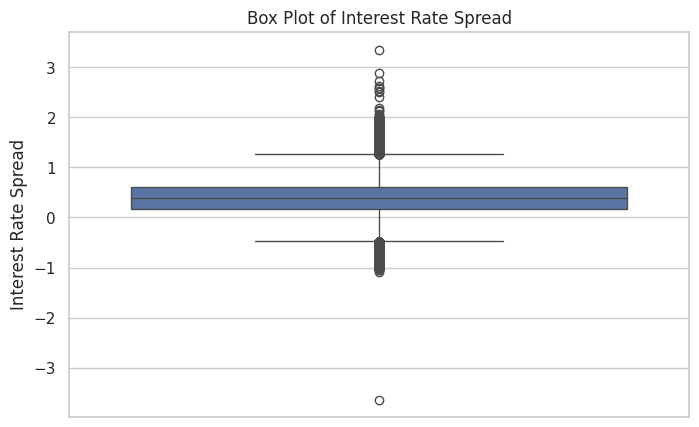

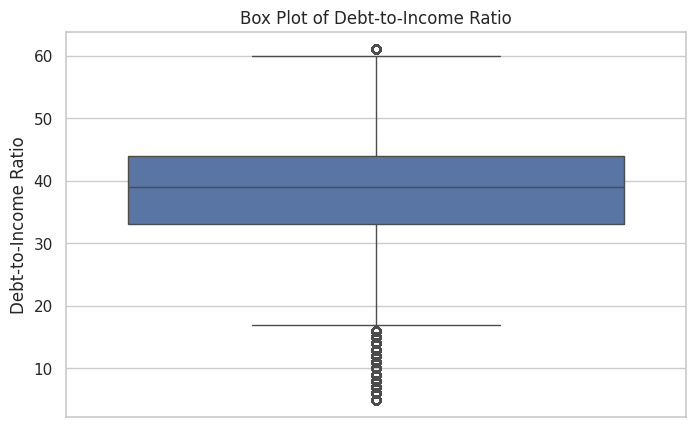

In [ ]:
#sns.boxplot(y='property_value', data=df)
#sns.boxplot(y='credit_score', data=df) #WORKS!!!
#sns.boxplot(y='income', data=df)
#sns.boxplot(y='rate_of_interest', data=df) #WORKS!!!
#sns.boxplot(y='interest_rate_spread', data=df) #WORKS!!!
#sns.boxplot(y='dtir1', data=df) #WORKS!!!
#######sns.boxplot(y='loan_purpose', data=df) #WORKS
# Box plots for columns marked as WORKS!!!

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(y='credit_score', data=df)
plt.title("Box Plot of Credit Score")
plt.ylabel("Credit Score")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y='rate_of_interest', data=df)
plt.title("Box Plot of Rate of Interest")
plt.ylabel("Rate of Interest")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y='interest_rate_spread', data=df)
plt.title("Box Plot of Interest Rate Spread")
plt.ylabel("Interest Rate Spread")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(y='dtir1', data=df)
plt.title("Box Plot of Debt-to-Income Ratio")
plt.ylabel("Debt-to-Income Ratio")
plt.show()

### Interactive Dashboard

The interactive dashboard was developed separately in Visual Studio Code using Dash and Plotly. This is because Dash runs as a local web application, which works more reliably in a local development environment than inside Google Colab.

The dashboard includes KPI cards, filters, and interactive charts for exploring loan default risk by year, region, and loan type.